In [2]:
import os
import time
import torch
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
import torchvision.transforms.functional as TF

import albumentations as A
from albumentations.pytorch import ToTensorV2
# jonathan hint: bei genug bild daten anderes vortrainiertes model vorschieben
#profiling einbauen um bottleneck zu finden

class SegmentationDataset(Dataset):
    def __init__(self, img_dir, mask_dir, patch_size=512, overlap=0.5, transform=None):
        self.img_paths = sorted([os.path.join(img_dir, f) for f in os.listdir(img_dir) if f.lower().endswith('.jpg')])
        self.mask_paths = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir) if f.lower().endswith('.png')])
        self.patch_size = patch_size
        self.step = int(patch_size * (1 - overlap))
        self.transform = transform
        self.patches = self._extract_patches()

    def _extract_patches(self):
        patches = []
        for img_path, mask_path in zip(self.img_paths, self.mask_paths):
            img = Image.open(img_path)
            width, height = img.size
            width = int(width / 2)
            height = int(height /2)
            img = img.resize((width, height), Image.Resampling.LANCZOS)
            mask = Image.open(mask_path).convert('L')
            mask = mask.resize((width, height), Image.Resampling.LANCZOS)
            w, h = img.size
            for y in range(0, h - self.patch_size + 1, self.step):
                for x in range(0, w - self.patch_size + 1, self.step):
                    patches.append((img_path, mask_path, x, y))
        return patches

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        img_path, mask_path, x, y = self.patches[idx]
        img = Image.open(img_path).crop((x, y, x+self.patch_size, y+self.patch_size))
        mask = Image.open(mask_path).crop((x, y, x+self.patch_size, y+self.patch_size))
        if self.transform:
            img, mask = self.transform(img, mask)
        return img, mask


In [3]:


class ToTensorAndEncode:
    def __init__(self, class_values):  # class_values: list of grayscale pixel values (e.g. [0, 85, 170])
        self.class_values = class_values
        self.img_tf = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

    def __call__(self, img, mask):
        img_t = self.img_tf(img)
        mask_np = np.array(mask, dtype=np.uint8)

        label_map = np.zeros_like(mask_np, dtype=np.int64)
        for idx, value in enumerate(self.class_values):
            label_map[mask_np == value] = idx

        """one_hot = np.zeros((self.num_classes, *label_map.shape), dtype=np.float32)
        for c in range(self.num_classes):
            one_hot[c] = (label_map == c)"""
        mask_t = torch.from_numpy(label_map).long()

        return img_t, mask_t


In [4]:


class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, n_classes, base_c=64):
        super().__init__()
        # Encoder
        self.down1 = DoubleConv(3, base_c)
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = DoubleConv(base_c, base_c*2)
        self.pool2 = nn.MaxPool2d(2)
        self.down3 = DoubleConv(base_c*2, base_c*4)
        self.pool3 = nn.MaxPool2d(2)
        self.down4 = DoubleConv(base_c*4, base_c*8)
        self.pool4 = nn.MaxPool2d(2)
        # Bottleneck
        self.bottleneck = DoubleConv(base_c*8, base_c*16)
        # Decoder
        self.up4 = nn.ConvTranspose2d(base_c*16, base_c*8, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(base_c*16, base_c*8)
        self.up3 = nn.ConvTranspose2d(base_c*8, base_c*4, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(base_c*8, base_c*4)
        self.up2 = nn.ConvTranspose2d(base_c*4, base_c*2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(base_c*4, base_c*2)
        self.up1 = nn.ConvTranspose2d(base_c*2, base_c, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(base_c*2, base_c)
        # Output
        self.outc = nn.Conv2d(base_c, n_classes, kernel_size=1)

    def forward(self, x):
        d1 = self.down1(x)
        p1 = self.pool1(d1)
        d2 = self.down2(p1)
        p2 = self.pool2(d2)
        d3 = self.down3(p2)
        p3 = self.pool3(d3)
        d4 = self.down4(p3)
        p4 = self.pool4(d4)

        bn = self.bottleneck(p4)

        u4 = self.up4(bn)
        c4 = self.dec4(torch.cat([u4, d4], dim=1))
        u3 = self.up3(c4)
        c3 = self.dec3(torch.cat([u3, d3], dim=1))
        u2 = self.up2(c3)
        c2 = self.dec2(torch.cat([u2, d2], dim=1))
        u1 = self.up1(c2)
        c1 = self.dec1(torch.cat([u1, d1], dim=1))

        return self.outc(c1)

In [10]:
class AugmentedDataset(Dataset):
    def __init__(self, img_dir, mask_dir, patch_size=512, overlap=0.5, transform=None):
        self.img_paths = sorted([
            os.path.join(img_dir, f) for f in os.listdir(img_dir) if f.lower().endswith('.jpg')
        ])
        self.mask_paths = sorted([
            os.path.join(mask_dir, f) for f in os.listdir(mask_dir) if f.lower().endswith('.png')
        ])
        self.patch_size = patch_size
        self.step = int(patch_size * (1 - overlap))
        self.transform = transform
        self.patches = self._extract_patches()

    def _extract_patches(self):
        patches = []
        for img_path, mask_path in zip(self.img_paths, self.mask_paths):
            img = Image.open(img_path)
            mask = Image.open(mask_path).convert('L')

            # Resize once
            width, height = img.size
            new_size = (width // 2, height // 2)
            img = img.resize(new_size, Image.Resampling.LANCZOS)
            mask = mask.resize(new_size, Image.Resampling.LANCZOS)

            # Pre-crop to patches
            w, h = new_size
            for y in range(0, h - self.patch_size + 1, self.step):
                for x in range(0, w - self.patch_size + 1, self.step):
                    img_patch = img.crop((x, y, x + self.patch_size, y + self.patch_size))
                    mask_patch = mask.crop((x, y, x + self.patch_size, y + self.patch_size))
                    for aug_type in range(8):  # 8 augmentations
                        patches.append((img_patch.copy(), mask_patch.copy(), aug_type))
        return patches

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        img, mask, aug_type = self.patches[idx]

        # Apply fast augmentation
        if aug_type in {1, 2, 3}:
            img = TF.rotate(img, angle=90 * aug_type)
            mask = TF.rotate(mask, angle=90 * aug_type)
        elif aug_type == 4:
            img = TF.hflip(img)
            mask = TF.hflip(mask)
        elif aug_type == 5:
            img = TF.vflip(img)
            mask = TF.vflip(mask)
        elif aug_type == 6:
            img = TF.vflip(TF.hflip(img))
            mask = TF.vflip(TF.hflip(mask))
        elif aug_type == 7:
            img = TF.hflip(TF.rotate(img, angle=90))
            mask = TF.hflip(TF.rotate(mask, angle=90))

        if self.transform:
            img, mask = self.transform(img, mask)

        return img, mask

In [7]:
def get_num_classes(mask_dir):
    unique_values = set()
    for filename in tqdm(os.listdir(mask_dir)):
        if filename.endswith(".png"):
            mask = np.array(Image.open(os.path.join(mask_dir, filename)).convert('L'))
            unique_values.update(np.unique(mask))
    return len(unique_values), unique_values
mask_path = 'images/masks'
n_classes, class_values = get_num_classes(mask_path)
print(f"Detected {n_classes} unique classes: {class_values}")

100%|██████████| 81/81 [00:17<00:00,  4.65it/s]

Detected 256 unique classes: {np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(4), np.uint8(5), np.uint8(6), np.uint8(7), np.uint8(8), np.uint8(9), np.uint8(10), np.uint8(11), np.uint8(12), np.uint8(13), np.uint8(14), np.uint8(15), np.uint8(16), np.uint8(17), np.uint8(18), np.uint8(19), np.uint8(20), np.uint8(21), np.uint8(22), np.uint8(23), np.uint8(24), np.uint8(25), np.uint8(26), np.uint8(27), np.uint8(28), np.uint8(29), np.uint8(30), np.uint8(31), np.uint8(32), np.uint8(33), np.uint8(34), np.uint8(35), np.uint8(36), np.uint8(37), np.uint8(38), np.uint8(39), np.uint8(40), np.uint8(41), np.uint8(42), np.uint8(43), np.uint8(44), np.uint8(45), np.uint8(46), np.uint8(47), np.uint8(48), np.uint8(49), np.uint8(50), np.uint8(51), np.uint8(52), np.uint8(53), np.uint8(54), np.uint8(55), np.uint8(56), np.uint8(57), np.uint8(58), np.uint8(59), np.uint8(60), np.uint8(61), np.uint8(62), np.uint8(63), np.uint8(64), np.uint8(65), np.uint8(66), np.uint8(67), np.uint8(68), np.uint8(69), 

In [11]:

# Hyperparameter
lr = 1e-4
epochs = 80
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Dataset & DataLoader
transform = ToTensorAndEncode(class_values=class_values)

train_ds = AugmentedDataset('images/imgs', 'images/masks', transform=transform)

val_ds   = SegmentationDataset('images/imgs',   'images/masks',   transform=transform)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=0)

val_loader   = DataLoader(val_ds,   batch_size=4, shuffle=False, num_workers=0)

# Modell, Optimizer, Scheduler
model = UNet(n_classes).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
best_iou = 0.0

def dice_coef(pred, target, eps=1e-6):
    # pred, target: one-hot [B, C, H, W]
    intersection = (pred * target).sum(dim=(2,3))
    union = pred.sum(dim=(2,3)) + target.sum(dim=(2,3))
    return ((2 * intersection + eps) / (union + eps)).mean()
def compute_class_weights(train_loader, n_classes):
    class_counts = [0] * n_classes
    for imgs, masks in tqdm(train_loader, desc="Counting class frequencies"):
        _, labels = masks.max(dim=1)  # Get the class labels from the masks
        for i in range(n_classes):
            class_counts[i] += (labels == i).sum().item()
    
    total_pixels = sum(class_counts)
    class_weights = [total_pixels / count if count != 0 else 1 for count in class_counts]
    class_weights = torch.tensor(class_weights).float().to(device)
    return class_weights

# Calculate class weights based on the training dataset
#class_weights = compute_class_weights(train_loader, n_classes)
class_weights = torch.tensor([1, 10, 100]).float().to(device)
print(class_weights)

tensor([  1.,  10., 100.], device='cuda:0')


In [7]:

t0 = time.time()
checkpoint = 'best_unet.pth'
losses = []
val_losses = []
def weighted_cross_entropy_loss(logits, masks, class_weights):
    return F.cross_entropy(logits, masks, weight=class_weights)

if os.path.exists(checkpoint):
    print(f"Loading saved model from {checkpoint}")
    model.load_state_dict(torch.load(checkpoint))
    model.eval()
for epoch in range(epochs):
    model.train()
    train_loss = 0
    class_counts = [0] *n_classes
    for imgs, masks in tqdm(train_loader, desc=f"Train Ep {epoch}"):
        imgs, masks = imgs.to(device), masks.to(device)
        logits = model(imgs)
        loss = weighted_cross_entropy_loss(logits, masks, class_weights)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    losses.append(train_loss)
    # Validierung
    model.eval()
    val_loss, val_dice = 0, 0
    with torch.no_grad():
        for imgs, masks in tqdm(val_loader, desc=f"Val"):
            imgs, masks = imgs.to(device), masks.to(device)

            logits = model(imgs)

            preds = F.softmax(logits, dim=1)
            val_loss += F.cross_entropy(logits, masks, weight=class_weights).item()
            pred_classes = preds.argmax(dim=1)
            for i in range(n_classes):
                class_counts[i] += (pred_classes == i).sum().item()
            masks_one_hot = F.one_hot(masks, num_classes=n_classes).permute(0, 3, 1, 2).float()
            val_dice += dice_coef(preds, masks_one_hot).item()
    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    val_dice /= len(val_loader)
    scheduler.step(val_loss)
    print(f"Epoch {epoch} — Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Dice: {val_dice:.4f}")
    print("Class Detection Counts (Train):")
    for i, count in enumerate(class_counts):
        print(f"Class {i}: {count} pixels detected")
    # Modell speichern
    if val_dice > best_iou:
        best_iou = val_dice
        torch.save(model.state_dict(), checkpoint)

Val: 100%|██████████| 945/945 [23:14<00:00,  1.48s/it]


Epoch 0 — Train Loss: 0.3442 | Val Loss: 0.9635 | Val Dice: 0.2298
Class Detection Counts (Train):
Class 0: 450749123 pixels detected
Class 1: 0 pixels detected
Class 2: 540155197 pixels detected


Val: 100%|██████████| 945/945 [23:17<00:00,  1.48s/it]


Epoch 1 — Train Loss: 0.2375 | Val Loss: 0.4270 | Val Dice: 0.3019
Class Detection Counts (Train):
Class 0: 690080494 pixels detected
Class 1: 0 pixels detected
Class 2: 300823826 pixels detected


Val: 100%|██████████| 945/945 [23:19<00:00,  1.48s/it]


...

Epoch 77 — Train Loss: 0.0237 | Val Loss: 0.9620 | Val Dice: 0.3638
Class Detection Counts (Train):
Class 0: 937486472 pixels detected
Class 1: 225711 pixels detected
Class 2: 53192137 pixels detected


Val: 100%|██████████| 945/945 [23:08<00:00,  1.47s/it]


Epoch 78 — Train Loss: 0.0237 | Val Loss: 1.2437 | Val Dice: 0.3597
Class Detection Counts (Train):
Class 0: 953263035 pixels detected
Class 1: 185601 pixels detected
Class 2: 37455684 pixels detected


Val: 100%|██████████| 945/945 [23:28<00:00,  1.49s/it]

Epoch 79 — Train Loss: 0.0239 | Val Loss: 0.9882 | Val Dice: 0.3630
Class Detection Counts (Train):
Class 0: 936891195 pixels detected
Class 1: 233358 pixels detected
Class 2: 53779767 pixels detected


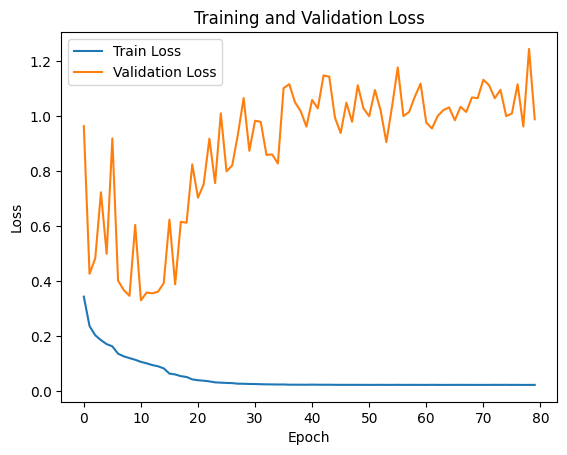

In [8]:

plt.plot(range(epochs), losses, label='Train Loss')
plt.plot(range(epochs), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

  0%|          | 0/10 [00:00<?, ?it/s]

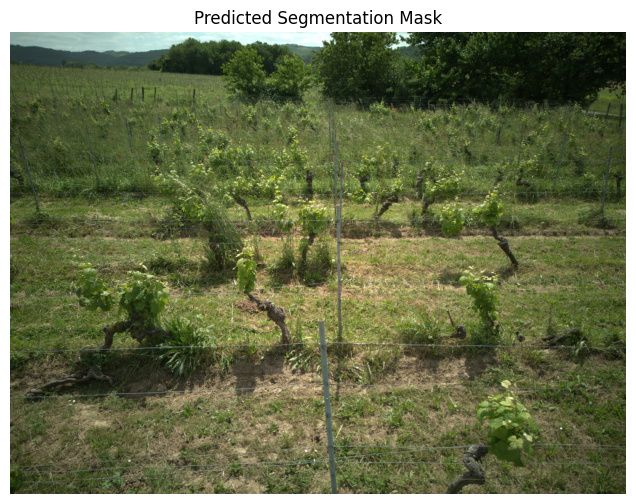

In [ ]:
checkpoint = 'best_unet.pth'
if os.path.exists(checkpoint):
    print(f"Loading saved model from {checkpoint}")
    model.load_state_dict(torch.load(checkpoint))
    model.eval()
def predict_img(net,
                full_img,
                device,
                out_threshold=0.5,
                class_values=None):
    """
    Predict the segmentation mask for a full PIL image using the given model.

    Args:
        net           : Trained segmentation model
        full_img      : PIL.Image input image (RGB)
        device        : torch.device
        out_threshold : Threshold for binary segmentation (ignored if multi-class)
        class_values  : Optional list of grayscale values for classes (for decoding)

    Returns:
        Numpy array of the predicted mask (HxW) as integers
    """
    net.eval()

    tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std= [0.229, 0.224, 0.225])
    ])  # Keine Normalisierung mehr
    img_tensor = tf(full_img).unsqueeze(0).to(device=device, dtype=torch.float32)

    with torch.no_grad():
        output = net(img_tensor)
        output = F.interpolate(output, size=full_img.size[::-1], mode='bilinear', align_corners=False)

        probs = F.softmax(output, dim=1)
        pred = torch.argmax(probs, dim=1).squeeze(0).cpu().numpy()

        if class_values:
            pred_mask = np.zeros_like(pred, dtype=np.uint8)
            for idx, val in enumerate(class_values):
                pred_mask[pred == idx] = val
        else:
            pred_mask = pred.astype(np.uint8)

    # Plotten des Vorhersage-Masks
    plt.figure(figsize=(8, 6))
    plt.imshow(pred_mask)
    plt.title("Predicted Segmentation Mask")
    plt.axis('off')
    plt.show()

    return pred_mask




    return pred_mask
for i in tqdm(os.listdir("images/imgs")):
    path ="images/imgs/" + i
    img = Image.open(path).convert("RGB")
    width, height = img.size
    width = int(width / 2)
    height = int(height /2)
    img = img.resize((width, height), Image.Resampling.LANCZOS)
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.title("Predicted Segmentation Mask")
    plt.axis('off')
    plt.show()
    pred_mask = predict_img(
        net=model,
        full_img=img,
        device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
        class_values=[0, 150, 255]  # optional, if your classes use specific grayscale values
    )
    out_path="some_image_mask.jpg"
    print(np.unique(pred_mask))
"""mask_img = Image.fromarray(pred_mask)
if pred_mask.ndim == 2:
    mask_img = mask_img.convert('L')
else:
    mask_img = mask_img.convert('RGB')

mask_img.save(out_path)"""